DT Train: 0.7331460674157303
DT Test:  0.7039106145251397
              precision    recall  f1-score   support

           0       0.71      0.91      0.80       105
           1       0.80      0.47      0.59        74

    accuracy                           0.73       179
   macro avg       0.75      0.69      0.70       179
weighted avg       0.75      0.73      0.71       179

RF2 Test: 0.7206703910614525
DT2 Train: 0.7331460674157303


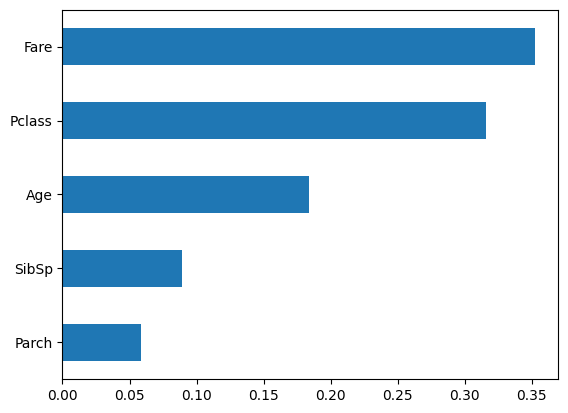

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('train.csv')
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop('Cabin', axis=1)

X = df[['Pclass', 'Age', 'Fare', 'SibSp', 'Parch']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Bug 1
dt = DecisionTreeClassifier(max_depth=3,random_state=42)
dt.fit(X_train, y_train)
print("DT Train:", dt.score(X_train, y_train))
print("DT Test: ", dt.score(X_test, y_test))

# Bug 2
rf = RandomForestClassifier(n_estimators=100, random_state=42,max_depth=3)
rf.fit(X_train, y_train)
print(classification_report( y_test,rf.predict(X_test)))

# Bug 3
importance = pd.Series(rf.feature_importances_,index=X.columns)
importance.sort_values().plot(kind='barh')

# Bug 4
rf2 = RandomForestClassifier(n_estimators=100,
                              max_depth=5,
                              random_state=42)
rf2.fit(X_train, y_train)
print("RF2 Test:", rf2.score(X_test, y_test))

# Bug 5
dt2 = DecisionTreeClassifier(max_depth=3,random_state=42)
dt2.fit(X_train, y_train)
print("DT2 Train:", dt2.score( X_train,y_train))